In [1]:
from google.colab import files

In [2]:
uploaded = files.upload()

Saving Tweets.csv to Tweets.csv


In [3]:
import pandas as pd

In [4]:
df = pd.read_csv('Tweets.csv')

In [5]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [6]:
!pip install vaderSentiment -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.5 MB/s eta 0:00:00


In [7]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [8]:
analyzer = SentimentIntensityAnalyzer()

In [11]:
def get_sentiment(text): score = analyzer.polarity_scores(str(text))['compound']; return 'Positive' if score >= 0.05 else 'Negative' if score <= -0.05 else 'Neutral'

In [13]:
df['calculated_sentiment'] = df['text'].apply(get_sentiment)

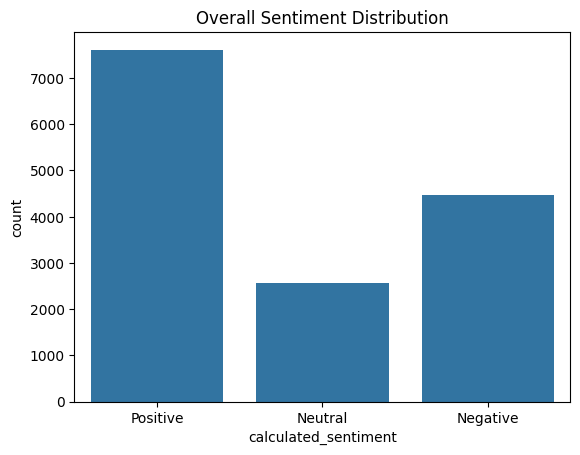

In [14]:
import seaborn as sns; import matplotlib.pyplot as plt; sns.countplot(x='calculated_sentiment', data=df, order=['Positive','Neutral','Negative']); plt.title('Overall Sentiment Distribution'); plt.show()

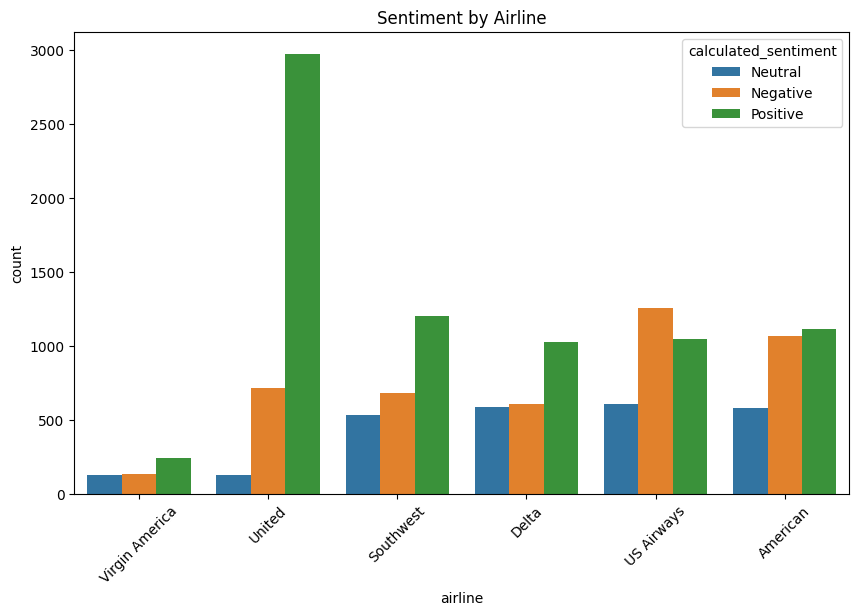

In [15]:
plt.figure(figsize=(10,6)); sns.countplot(x='airline', hue='calculated_sentiment', data=df); plt.title('Sentiment by Airline'); plt.xticks(rotation=45); plt.show()

In [17]:
!pip install wordcloud -q

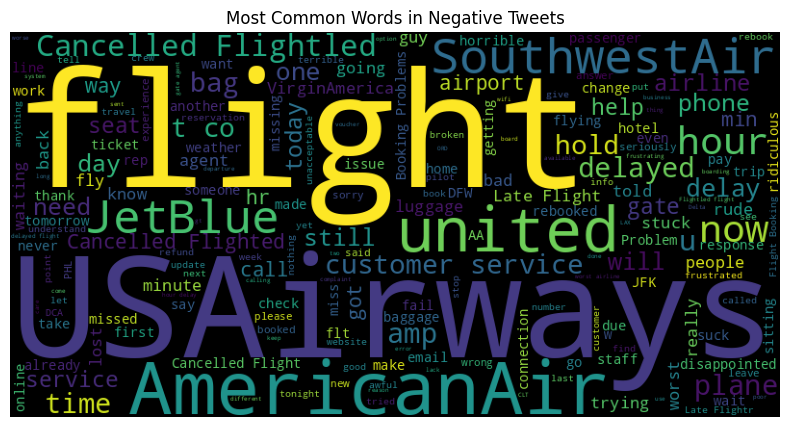

In [18]:
from wordcloud import WordCloud; negative_text = ' '.join(df[df['calculated_sentiment']=='Negative']['text']); wc = WordCloud(width=800, height=400, background_color='black').generate(negative_text); plt.figure(figsize=(10,5)); plt.imshow(wc); plt.axis('off'); plt.title('Most Common Words in Negative Tweets'); plt.show()